# PTA Likelihood vs Pulsar Distance

This notebook demonstrates how the PTA log-likelihood varies as a function of
a single pulsar's distance in the presence of a continuous gravitational wave (CW) source.

We generate **N** random pulsars (white noise + spindown timing models) and
**M** CW sources, then sweep the distance of one pulsar while holding everything
else fixed.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt 

In [2]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")  # silence PINT's DEBUG/INFO chatter

from io import StringIO

import jax
import jax.numpy as jnp
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.types import GlobalParams
from jaxpint.pta.signals.cw import CWInjector
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_1d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 100  # plots up to M CW sources on same graph
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0    # ~8 yr observation span
TOA_ERROR = 1e-8     # 10 ns (reduced to make CW signal prominent)
FREQ = 1400.0        # MHz
SEED = 42


## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, DM, and
distance. We build a minimal `.par` string and parse it with PINT.

**Convention:** `PX` is stored as parallax in **mas** (the PINT / `types.py`
convention used by the astrometric parallax delay). `CWInjector` converts
internally to distance in kpc via `L_kpc = 1 / PX_mas` and feeds that into
the Ellis+2012 pulsar-term phase. Sweeps below are done in mas; plots are
displayed on a kpc axis via the same `1 / PX_mas` mapping.

In [3]:
rng = np.random.default_rng(SEED)

par_strings = [
    generate_random_par(
        idx, rng,
        start_mjd=START_MJD,
        include_dm=True,
        extra_params={"EQUAD tel gbt": "0.1"},
    )
    for idx in range(N_PULSARS)
]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
DM            49.0249
PX            1.359724
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
EQUAD tel gbt 0.1



## Generate fake TOAs and convert to JaxPINT

In [4]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD,
    end_mjd=END_MJD,
    n_toas=N_TOAS,
    toa_error_s=TOA_ERROR,
    freq_mhz=FREQ,
)
# Aliases matching the rest of the notebook
toa_data_list = list(synthetic.toa_data_list)
pulsar_params_list = list(synthetic.pulsar_params_list)
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
base_toa_data_list = list(synthetic.toa_data_list)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_mas = float(pulsar_params_list[i].param_value("PX"))
    distance_kpc = 1.0 / px_mas
    f0_val = float(pulsar_params_list[i].param_value("F0"))
    print(
        f"  Pulsar {i}: {model.PSR.value:>20s}  "
        f"PX={px_mas:.3f} mas (d={distance_kpc:.2f} kpc)  F0={f0_val:.1f} Hz"
    )

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_

  Pulsar 0:        J1834-0701_00  PX=1.360 mas (d=0.74 kpc)  F0=443.4 Hz
  Pulsar 1:        J1816+3453_01  PX=0.701 mas (d=1.43 kpc)  F0=151.2 Hz
  Pulsar 2:        J1527+4012_02  PX=0.530 mas (d=1.89 kpc)  F0=277.4 Hz
  Pulsar 3:        J1951+1516_03  PX=0.342 mas (d=2.93 kpc)  F0=403.2 Hz
  Pulsar 4:        J1840-3738_04  PX=1.129 mas (d=0.89 kpc)  F0=286.7 Hz
  Pulsar 5:        J1752+6913_05  PX=0.597 mas (d=1.67 kpc)  F0=230.3 Hz
  Pulsar 6:        J0307-0247_06  PX=0.628 mas (d=1.59 kpc)  F0=190.8 Hz
  Pulsar 7:        J1648-2202_07  PX=0.681 mas (d=1.47 kpc)  F0=432.9 Hz
  Pulsar 8:        J1622-4605_08  PX=0.405 mas (d=2.47 kpc)  F0=180.0 Hz
  Pulsar 9:        J1655+3409_09  PX=1.177 mas (d=0.85 kpc)  F0=283.6 Hz

All 10 pulsars loaded.


## Set up CW source and PTA config

We place several CW sources at a random sky location with random nHz GW frequency  and
strain amplitude $h \sim 10^{-12}$.

In [5]:
all_cw_injectors, positions = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-12.0,
)
all_cw_injectors = list(all_cw_injectors)

for m, inj in enumerate(all_cw_injectors):
    print(
        f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
        f"gwphi={inj.param_spec['gwphi']:.3f}, log10_fgw={inj.param_spec['log10_fgw']:.2f}"
    )

print(f"\nGenerated {M_CW_SOURCES} CW sources total")


  CW source 0: cos_gwtheta=0.337, gwphi=2.960, log10_fgw=-7.87
  CW source 1: cos_gwtheta=0.530, gwphi=3.988, log10_fgw=-7.89
  CW source 2: cos_gwtheta=0.118, gwphi=1.910, log10_fgw=-8.94
  CW source 3: cos_gwtheta=-0.127, gwphi=1.348, log10_fgw=-8.18
  CW source 4: cos_gwtheta=0.707, gwphi=1.470, log10_fgw=-8.88
  CW source 5: cos_gwtheta=-0.437, gwphi=1.845, log10_fgw=-7.68
  CW source 6: cos_gwtheta=0.114, gwphi=4.925, log10_fgw=-7.67
  CW source 7: cos_gwtheta=-0.187, gwphi=5.115, log10_fgw=-8.67
  CW source 8: cos_gwtheta=-0.955, gwphi=0.566, log10_fgw=-7.56
  CW source 9: cos_gwtheta=-0.076, gwphi=1.013, log10_fgw=-8.00
  CW source 10: cos_gwtheta=-0.695, gwphi=4.375, log10_fgw=-8.11
  CW source 11: cos_gwtheta=-0.238, gwphi=1.894, log10_fgw=-7.74
  CW source 12: cos_gwtheta=-0.276, gwphi=0.551, log10_fgw=-8.76
  CW source 13: cos_gwtheta=0.924, gwphi=5.709, log10_fgw=-7.60
  CW source 14: cos_gwtheta=-0.468, gwphi=6.090, log10_fgw=-7.44
  CW source 15: cos_gwtheta=0.434, gwphi=

## Sweep distance for pulsar 0

We vary the distance (PX parameter) of pulsar 0 over a grid while keeping all
other parameters fixed, and evaluate the PTA log-likelihood at each point.

The CW pulsar-term phase depends on distance as
$\phi_p = \phi_e - 2\pi f_{\rm gw} \frac{d}{c}(1 + \cos\mu)$,
so the likelihood oscillates with distance.

In [6]:
TARGET_PULSAR = 0
true_px_mas = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
true_distance = 1.0 / true_px_mas  # kpc
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc "
      f"(PX = {true_px_mas:.4f} mas)")

# Build the sweep grid in kpc for display, then invert to mas for the sweep
# so the likelihood sees the physically correct parallax values.
half_window = 0.01  # kpc
distance_grid = np.linspace(
    true_distance - half_window,
    true_distance + half_window,
    500,
)
px_mas_grid = 1.0 / distance_grid

M_values = [1, 2, 5, 10, 20, 50, M_CW_SOURCES]
results = {}  # M -> logL_values

for M in M_values:
    print(f"\n--- M = {M} CW source(s) ---")
    cw_subset = all_cw_injectors[:M]
    gp, cfg = inject_and_build_config(synthetic, cw_subset)

    def _eval(px_mas_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    results[M] = sweep_1d_logL(_eval, px_mas_grid)
    print(f"  Sweep complete ({len(px_mas_grid)} points)")

print("\nAll sweeps done.")

Pulsar 0 true distance: 0.735 kpc (PX = 1.3597 mas)

--- M = 1 CW source(s) ---
  Sweep complete (500 points)

--- M = 2 CW source(s) ---
  Sweep complete (500 points)

--- M = 5 CW source(s) ---
  Sweep complete (500 points)

--- M = 10 CW source(s) ---
  Sweep complete (500 points)

--- M = 20 CW source(s) ---
  Sweep complete (500 points)

--- M = 50 CW source(s) ---
  Sweep complete (500 points)

--- M = 100 CW source(s) ---
  Sweep complete (500 points)

All sweeps done.


## Plot Likelihood

JaxPINT WLS fitter result for pulsar 0:
  PX = 1.359775 +/- 0.018032 mas (1-sigma)  ->  sigma_d = 0.009753 kpc


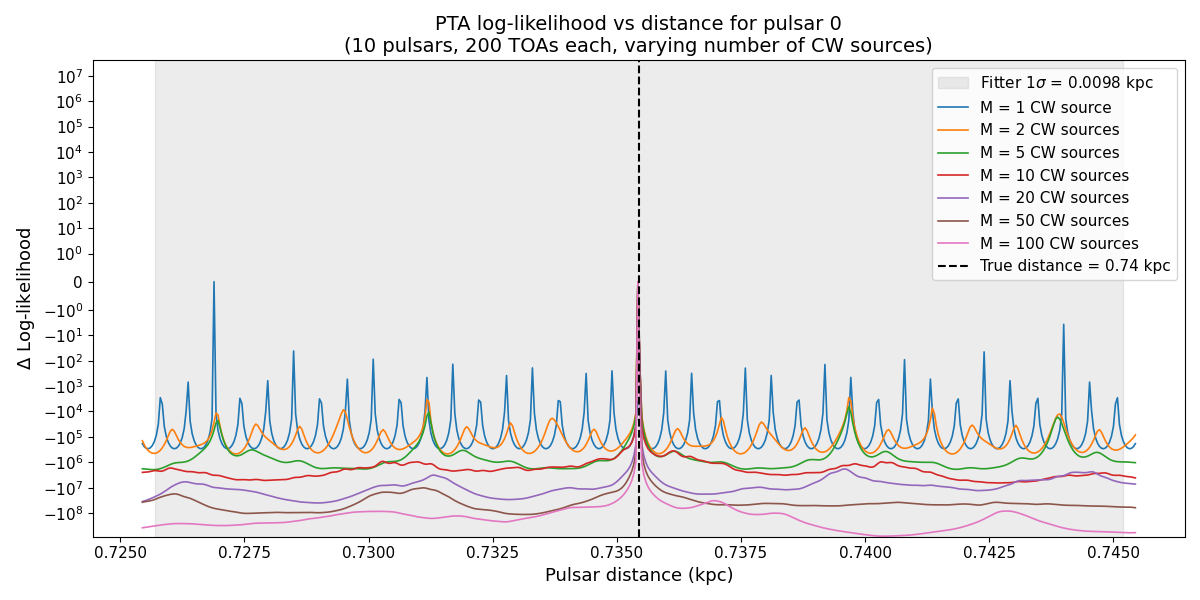

In [7]:
# Fit the target pulsar with JaxPINT's WLS fitter to get PX uncertainty
from jaxpint.fitters import WLSFitter
from jaxpint.types import ParameterVector
import matplotlib.pyplot as plt

target_params = pp_tuple[TARGET_PULSAR]
px_idx = target_params.names.index("PX")
new_frozen = list(target_params.frozen_mask)
new_frozen[px_idx] = False
fit_params = ParameterVector(
    values=target_params.values,
    frozen_mask=tuple(new_frozen),
    names=target_params.names,
    units=target_params.units,
    epoch_int_values=target_params.epoch_int_values,
)

fitter = WLSFitter(
    timing_models[TARGET_PULSAR],
    base_toa_data_list[TARGET_PULSAR],
    fit_params,
    noise_models[TARGET_PULSAR],
)
fit_result = fitter.fit_toas()

free_names = [fit_params.names[i] for i in fit_params._free_indices]
px_free_idx = free_names.index("PX")
px_err_mas = float(fit_result.parameter_uncertainties[px_free_idx])
# d = 1 / PX, so sigma_d = |d(d)/d(PX)| * sigma_PX = sigma_PX / PX^2 = d^2 * sigma_PX
px_err = px_err_mas * true_distance ** 2  # kpc

print(f"JaxPINT WLS fitter result for pulsar {TARGET_PULSAR}:")
print(
    f"  PX = {float(fit_result.params.param_value('PX')):.6f} +/- "
    f"{px_err_mas:.6f} mas (1-sigma)  ->  sigma_d = {px_err:.6f} kpc"
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.axvspan(
    true_distance - px_err, true_distance + px_err,
    alpha=0.15, color="gray", label=f"Fitter 1$\\sigma$ = {px_err:.4f} kpc",
)
for M in M_values:
    plot_1d_delta_logL(
        ax, distance_grid, results[M],
        label=f"M = {M} CW source{'s' if M > 1 else ''}",
    )
ax.axvline(
    true_distance, color="black", linestyle="--", linewidth=1.5,
    label=f"True distance = {true_distance:.2f} kpc",
)
ax.set_yscale("symlog", linthresh=1e0)
ax.set_xlabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA log-likelihood vs distance for pulsar {TARGET_PULSAR}\n"
    f"({N_PULSARS} pulsars, {N_TOAS} TOAs each, varying number of CW sources)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()

## Fisher Information Analysis

The Fisher information $F = -\frac{d^2 \log L}{d(\text{PX})^2}$ at the true distance
quantifies how tightly the likelihood constrains the distance. The Cramér-Rao bound
gives the minimum uncertainty: $\sigma_d \geq 1/\sqrt{F}$.

### Fisher information vs number of CW sources


In [8]:
M_sweep = [1, 2, 5, 10, 20, 50, M_CW_SOURCES]
fisher_vs_M = []
sigma_vs_M = []

for M in M_sweep:
    cw_subset = all_cw_injectors[:M]
    gp, cfg = inject_and_build_config(synthetic, cw_subset)

    @jax.jit
    def _eval_fisher(px_mas_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    # Fisher info w.r.t. PX (mas); linearise to distance via sigma_d = d^2 * sigma_PX.
    F_mas = float(-jax.jit(jax.grad(jax.grad(_eval_fisher)))(jnp.float64(true_px_mas)))
    sigma_px_mas = 1.0 / np.sqrt(abs(F_mas))
    sigma_d_kpc = sigma_px_mas * true_distance ** 2
    fisher_vs_M.append(F_mas)
    sigma_vs_M.append(sigma_d_kpc)

    if M % 10 == 0 or M <= 5:
        print(f"  M={M:3d}: F_PX={F_mas:.4e} mas^-2, sigma_d={sigma_d_kpc:.4e} kpc")

fisher_vs_M = np.array(fisher_vs_M)
sigma_vs_M = np.array(sigma_vs_M)
print("Done.")

  M=  1: F_PX=5.9648e+12 mas^-2, sigma_d=2.2146e-07 kpc
  M=  2: F_PX=2.4906e+12 mas^-2, sigma_d=3.4272e-07 kpc
  M=  5: F_PX=3.0093e+12 mas^-2, sigma_d=3.1179e-07 kpc
  M= 10: F_PX=7.5881e+12 mas^-2, sigma_d=1.9635e-07 kpc
  M= 20: F_PX=3.7571e+13 mas^-2, sigma_d=8.8242e-08 kpc
  M= 50: F_PX=8.3433e+13 mas^-2, sigma_d=5.9215e-08 kpc
  M=100: F_PX=2.0756e+14 mas^-2, sigma_d=3.7543e-08 kpc
Done.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fisher info vs M
ax1.loglog(M_sweep, fisher_vs_M, "o-", markersize=3, linewidth=1.2)
# Reference: linear scaling from M=1
ax1.loglog(M_sweep, fisher_vs_M[0] * np.array(M_sweep), "--", color="gray",
           alpha=0.6, label="$\\propto M$ (independent sources)")
ax1.set_xlabel("Number of CW sources (M)", fontsize=13)
ax1.set_ylabel("Fisher information $F$", fontsize=13)
ax1.set_title("Fisher info vs M", fontsize=14)
ax1.legend(fontsize=11)
ax1.tick_params(labelsize=11)

# sigma_d vs M
ax2.loglog(M_sweep, sigma_vs_M * 1e3, "o-", markersize=3, linewidth=1.2)  # convert to pc
ax2.loglog(M_sweep, sigma_vs_M[0] * 1e3 / np.sqrt(M_sweep), "--", color="gray",
           alpha=0.6, label="$\\propto 1/\\sqrt{M}$")
ax2.axhline(px_err * 1e3, color="red", linestyle=":", linewidth=1.5,
            label=f"Fitter $\\sigma$ = {px_err*1e3:.1f} pc")
ax2.set_xlabel("Number of CW sources (M)", fontsize=13)
ax2.set_ylabel("$\\sigma_d$ (pc)", fontsize=13)  
ax2.set_title("Distance uncertainty vs M", fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()

ValueError: 
$\propto M$ (independent sources)
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

### Fisher information vs GW frequency

Fix M=1 and sweep the CW source frequency. Higher frequency means faster
distance oscillations (shorter wavelength in distance space), which should
increase the local curvature of the likelihood peak.

In [ ]:
# Use CW source 0 as a template, varying only log10_fgw
template_spec = dict(all_cw_injectors[0].param_spec)

log10_fgw_grid = np.linspace(-9, -7, 40)
fisher_vs_freq = []
sigma_vs_freq = []

for log10_f in log10_fgw_grid:
    spec = dict(template_spec)
    spec["log10_fgw"] = float(log10_f)
    inj = CWInjector(positions, prefix="cwfreq_", initial_values=spec)
    gp, cfg = inject_and_build_config(synthetic, (inj,))

    @jax.jit
    def _eval_freq(px_mas_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F_mas = float(-jax.jit(jax.grad(jax.grad(_eval_freq)))(jnp.float64(true_px_mas)))
    fisher_vs_freq.append(F_mas)
    sigma_vs_freq.append((1.0 / np.sqrt(abs(F_mas))) * true_distance ** 2)

fisher_vs_freq = np.array(fisher_vs_freq)
sigma_vs_freq = np.array(sigma_vs_freq)
print("Done.")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(log10_fgw_grid, fisher_vs_freq, "o-", markersize=4, linewidth=1.2)
ax1.set_xlabel("$\\log_{10}(f_{\\rm gw}$ / Hz)", fontsize=13)
ax1.set_ylabel("Fisher information $F$", fontsize=13)
ax1.set_title("Fisher info vs GW frequency (M=1)", fontsize=14)
ax1.tick_params(labelsize=11)

ax2.semilogy(log10_fgw_grid, sigma_vs_freq * 1e3, "o-", markersize=4, linewidth=1.2)
ax2.axhline(px_err * 1e3, color="red", linestyle=":", linewidth=1.5,
            label=f"Fitter $\\sigma$ = {px_err*1e3:.1f} pc")
ax2.set_xlabel("$\\log_{10}(f_{\\rm gw}$ / Hz)", fontsize=13)
ax2.set_ylabel("$\\sigma_d$ (pc)", fontsize=13)
ax2.set_title("Distance uncertainty vs GW frequency (M=1)", fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()

### Fisher information vs CW strain amplitude

Fix M=1 and sweep `log10_h`. Since the CW delay scales as $h / (2\pi f_{\rm gw})$,
the signal-to-noise ratio scales linearly with $h$, so we expect $F \propto h^2$.

In [ ]:
# Use CW source 0 as a template, varying only log10_h
template_spec_h = dict(all_cw_injectors[0].param_spec)

log10_h_grid = np.linspace(-15, -11, 40)
fisher_vs_h = []
sigma_vs_h = []

for log10_h in log10_h_grid:
    spec = dict(template_spec_h)
    spec["log10_h"] = float(log10_h)
    inj = CWInjector(positions, prefix="cwamp_", initial_values=spec)
    gp, cfg = inject_and_build_config(synthetic, (inj,))

    @jax.jit
    def _eval_amp(px_mas_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F_mas = float(-jax.jit(jax.grad(jax.grad(_eval_amp)))(jnp.float64(true_px_mas)))
    fisher_vs_h.append(F_mas)
    sigma_vs_h.append((1.0 / np.sqrt(abs(F_mas))) * true_distance ** 2)

fisher_vs_h = np.array(fisher_vs_h)
sigma_vs_h = np.array(sigma_vs_h)
print("Done.")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(log10_h_grid, fisher_vs_h, 'o-', markersize=4, linewidth=1.2)
# Reference: h^2 scaling
h_ref = 10.0 ** log10_h_grid
h0 = 10.0 ** log10_h_grid[len(log10_h_grid)//2]
F0 = fisher_vs_h[len(log10_h_grid)//2]
ax1.semilogy(log10_h_grid, F0 * (h_ref / h0)**2, '--', color='gray',
             alpha=0.6, label='$\\propto h^2$')
ax1.set_xlabel('$\\log_{10}(h)$', fontsize=13)
ax1.set_ylabel('Fisher information $F$', fontsize=13)
ax1.set_title('Fisher info vs strain amplitude (M=1)', fontsize=14)
ax1.legend(fontsize=11)
ax1.tick_params(labelsize=11)

ax2.semilogy(log10_h_grid, sigma_vs_h * 1e3, 'o-', markersize=4, linewidth=1.2)
ax2.axhline(px_err * 1e3, color='red', linestyle=':', linewidth=1.5,
            label=f'Fitter $\\sigma$ = {px_err*1e3:.1f} pc')
ax2.set_xlabel('$\\log_{10}(h)$', fontsize=13)
ax2.set_ylabel('$\\sigma_d$ (pc)', fontsize=13)
ax2.set_title('Distance uncertainty vs strain amplitude (M=1)', fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()